In [1]:
import pandas as pd
import numpy as np
import seaborn as sb

In [2]:
df = sb.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [3]:
# find avg bill of males and females
df.groupby('sex')[['total_bill']].mean()

,total_bill
sex,
Male,20.744076
Female,18.056897


In [4]:
# find avg bill of smoker & non_smoker male & female customers
df.groupby(['sex' ,'smoker'] )[['total_bill']].mean().unstack()

total_bill           
smoker        Yes         No
sex                         
Male    22.284500  19.791237
Female  17.977879  18.105185

# Pivot table

You can use it to get same result

Usually pivot table is applied on categorical data

In [5]:
# by default agg in pivot_table is mean
pd.pivot_table(data= df ,index='sex' , columns='smoker' , values='total_bill')

smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [6]:
df.pivot_table(index='sex' ,columns='smoker' , values=['total_bill' ,'tip' ,'size'] , aggfunc='mean')

size                 tip           total_bill           
smoker       Yes        No       Yes        No        Yes         No
sex                                                                 
Male    2.500000  2.711340  3.051167  3.113402  22.284500  19.791237
Female  2.242424  2.592593  2.931515  2.773519  17.977879  18.105185

In [7]:
df.pivot_table(index='sex' , columns= 'smoker' , values=['tip'] , aggfunc='sum')

tip        
smoker     Yes      No
sex                   
Male    183.07  302.00
Female   96.74  149.77

In [8]:

df.head(2)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3


In [9]:
# MULTI_INDEX
# we have to find in our male & female cstomers on a particular day at a specific time like lunch/dinner
# the avg bill they pay
df.pivot_table(index=['sex' , 'smoker']  , columns=['day' , 'time'] , values='total_bill' , aggfunc='mean')

day                 Thur               Fri                Sat        Sun
time               Lunch Dinner      Lunch  Dinner     Dinner     Dinner
sex    smoker                                                           
Male   Yes     19.171000    NaN  11.386667  25.892  21.837778  26.141333
       No      18.486500    NaN        NaN  17.475  19.929063  20.403256
Female Yes     19.218571    NaN  13.260000  12.200  20.266667  16.540000
       No      15.899167  18.78  15.980000  22.750  19.003846  20.824286

In [10]:
# margins (adds a column and row of total(sum) of that particular column and row)
df.pivot_table(index='sex' , columns='smoker' , values='total_bill' , aggfunc='sum' , margins=True )

smoker,Yes,No,All
sex,,,
Male,1337.07,1919.75,3256.82
Female,593.27,977.68,1570.95
All,1930.34,2897.43,4827.77


# Expense_DataSet

In [11]:
# plotting graphs
df2= pd.read_csv('C:/Users/Lenovo/Desktop/Python/Pandas/DateTime,Pivot Table ,String opr in Pandas/expense_data.csv')

In [12]:
df2.head(3)

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0


In [13]:
# to deal with dates
df2['Date'] = pd.to_datetime(df2['Date'])

In [14]:
# now
df2['Month'] = df2['Date'].dt.month_name() # creating a month column for analysis

In [15]:
monthly_expense = df2.pivot_table(index='Month' , values='Amount' , aggfunc='sum' , observed=True)
monthly_expense

,Amount
Month,
December,27538.72
February,36064.65
January,40320.51
March,1125.00
November,7623.40


<Axes: xlabel='Month'>

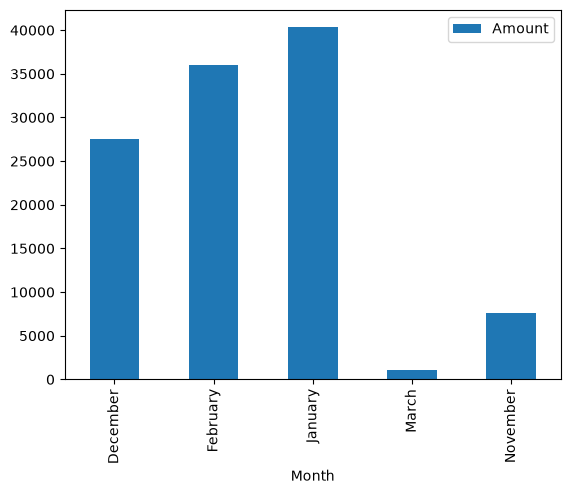

In [16]:
monthly_expense.plot(kind='bar')

In [17]:
month_catg = df2.pivot_table(index='Month' ,columns='Category' , values='Amount' , aggfunc='sum',fill_value=0 )
month_catg

Category,Allowance,Apparel,Beauty,Education,Food,Gift,Household,Other,Petty cash,Salary,Self-development,Social Life,Transportation
Month,,,,,,,,,,,,,
December,11000.0,2590.0,196.0,0.0,5335.00,0.0,4800.0,1790.0,0.0,0.0,400.0,513.72,914.0
February,0.0,798.0,0.0,0.0,5579.85,0.0,2808.0,20000.0,0.0,0.0,0.0,1800.00,5078.8
January,1000.0,0.0,0.0,1400.0,9112.51,0.0,4580.0,13178.0,0.0,8000.0,0.0,200.00,2850.0
March,0.0,0.0,0.0,0.0,195.00,0.0,0.0,900.0,0.0,0.0,0.0,0.00,30.0
November,2000.0,0.0,0.0,0.0,3174.40,115.0,0.0,2000.0,3.0,0.0,0.0,0.00,331.0


<Axes: xlabel='Month'>

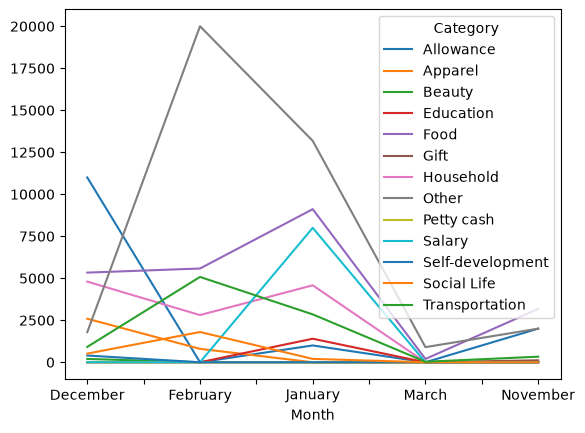

In [18]:
month_catg.plot()

In [19]:
df2.pivot_table(index='Month' ,columns='Account' , values='INR' , aggfunc='sum' ,fill_value=0)

Account,CUB - online payment,Cash
Month,,
December,27523.72,1120.72
February,36064.65,0.00
January,40320.51,0.00
March,1125.00,0.00
November,7623.40,0.00


<Axes: xlabel='Month'>

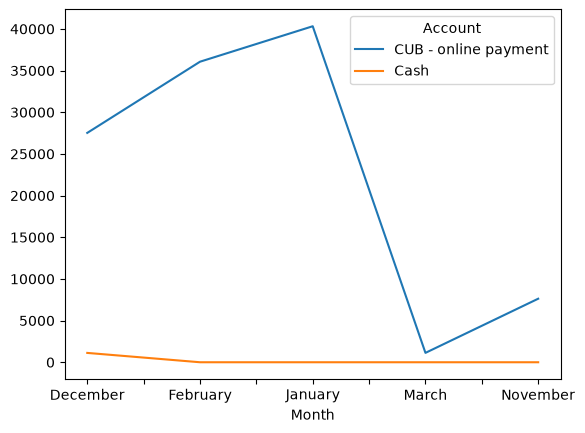

In [20]:
df2.pivot_table(index='Month' ,columns='Account' , values='INR' , aggfunc='sum' ,fill_value=0).plot()